In [2]:
#Import necessary libraries
from scipy.stats import qmc
import numpy as np
import pandas as pd

from scipy.stats import norm
from scipy.optimize import minimize
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import Matern

In [3]:
#Function 8
#Extracting updated data and turning it into a pandas dataframe
data = pd.read_csv('Data/Week 6 - Function 8.csv') 
columns = ['Input 1', 'Input 2', 'Input 3', 'Input 4', 'Input 5', 'Input 6', 
           'Input 7', 'Input 8','Outputs']
#Remove columns with NaN values
data = data.dropna(axis = 1)
data.columns = columns
#Add Week 7's data to our pandas dataframe
new_data7 = np.array([0.006676, 0.142850, 0.014612, 0.008493, 0.013195, 0.029041, 0.146052, 0.709045
                     ,9.384219448563])
data.loc[len(data)] = new_data7
data





,Input 1,Input 2,Input 3,Input 4,Input 5,Input 6,Input 7,Input 8,Outputs
0,0.604994,0.292215,0.908453,0.355506,0.201669,0.575338,0.310311,0.734281,7.398721
1,0.178007,0.566223,0.994862,0.210325,0.320153,0.707909,0.635384,0.107132,7.005227
2,0.009077,0.811626,0.520520,0.075687,0.265112,0.091652,0.592415,0.367320,8.459482
3,0.506028,0.653730,0.363411,0.177981,0.093728,0.197425,0.755827,0.292472,8.284008
4,0.359909,0.249076,0.495997,0.709215,0.114987,0.289207,0.557295,0.593882,8.606117
5,0.778818,0.003419,0.337983,0.519528,0.820907,0.537247,0.551347,0.660032,8.541748
6,0.908649,0.062250,0.238260,0.766604,0.132336,0.990244,0.688068,0.742496,7.327435
7,0.586371,0.880736,0.745021,0.546035,0.009649,0.748992,0.230907,0.097916,7.299872
8,0.761137,0.854672,0.382124,0.337352,0.689708,0.309853,0.631380,0.041956,7.957875
9,0.984933,0.699506,0.998885,0.180148,0.580143,0.231087,0.490827,0.313683,5.592193


In [4]:
#Extract the Data Into Numpy Arrays
X = np.array(data[['Input 1', 'Input 2', 'Input 3', 'Input 4', 'Input 5'
                  ,'Input 6', 'Input 7', 'Input 8']])
Y = np.array(data[['Outputs']])



In [5]:
# Find the pearson correlations matrix
data.corr(method = 'pearson')

,Input 1,Input 2,Input 3,Input 4,Input 5,Input 6,Input 7,Input 8,Outputs
Input 1,1.000000,0.297788,0.272513,0.202107,0.187941,0.114937,0.333570,0.032208,-0.716251
Input 2,0.297788,1.000000,0.251700,-0.069292,0.034815,-0.038846,-0.020286,-0.282412,-0.374439
Input 3,0.272513,0.251700,1.000000,0.156654,-0.092084,-0.168894,0.101438,-0.053907,-0.730407
Input 4,0.202107,-0.069292,0.156654,1.000000,0.022145,0.016859,-0.014632,0.173154,-0.217443
Input 5,0.187941,0.034815,-0.092084,0.022145,1.000000,0.102946,0.044603,-0.053043,-0.056364
Input 6,0.114937,-0.038846,-0.168894,0.016859,0.102946,1.000000,0.007066,0.043248,0.056755
Input 7,0.333570,-0.020286,0.101438,-0.014632,0.044603,0.007066,1.000000,-0.091117,-0.452449
Input 8,0.032208,-0.282412,-0.053907,0.173154,-0.053043,0.043248,-0.091117,1.000000,0.117491
Outputs,-0.716251,-0.374439,-0.730407,-0.217443,-0.056364,0.056755,-0.452449,0.117491,1.000000


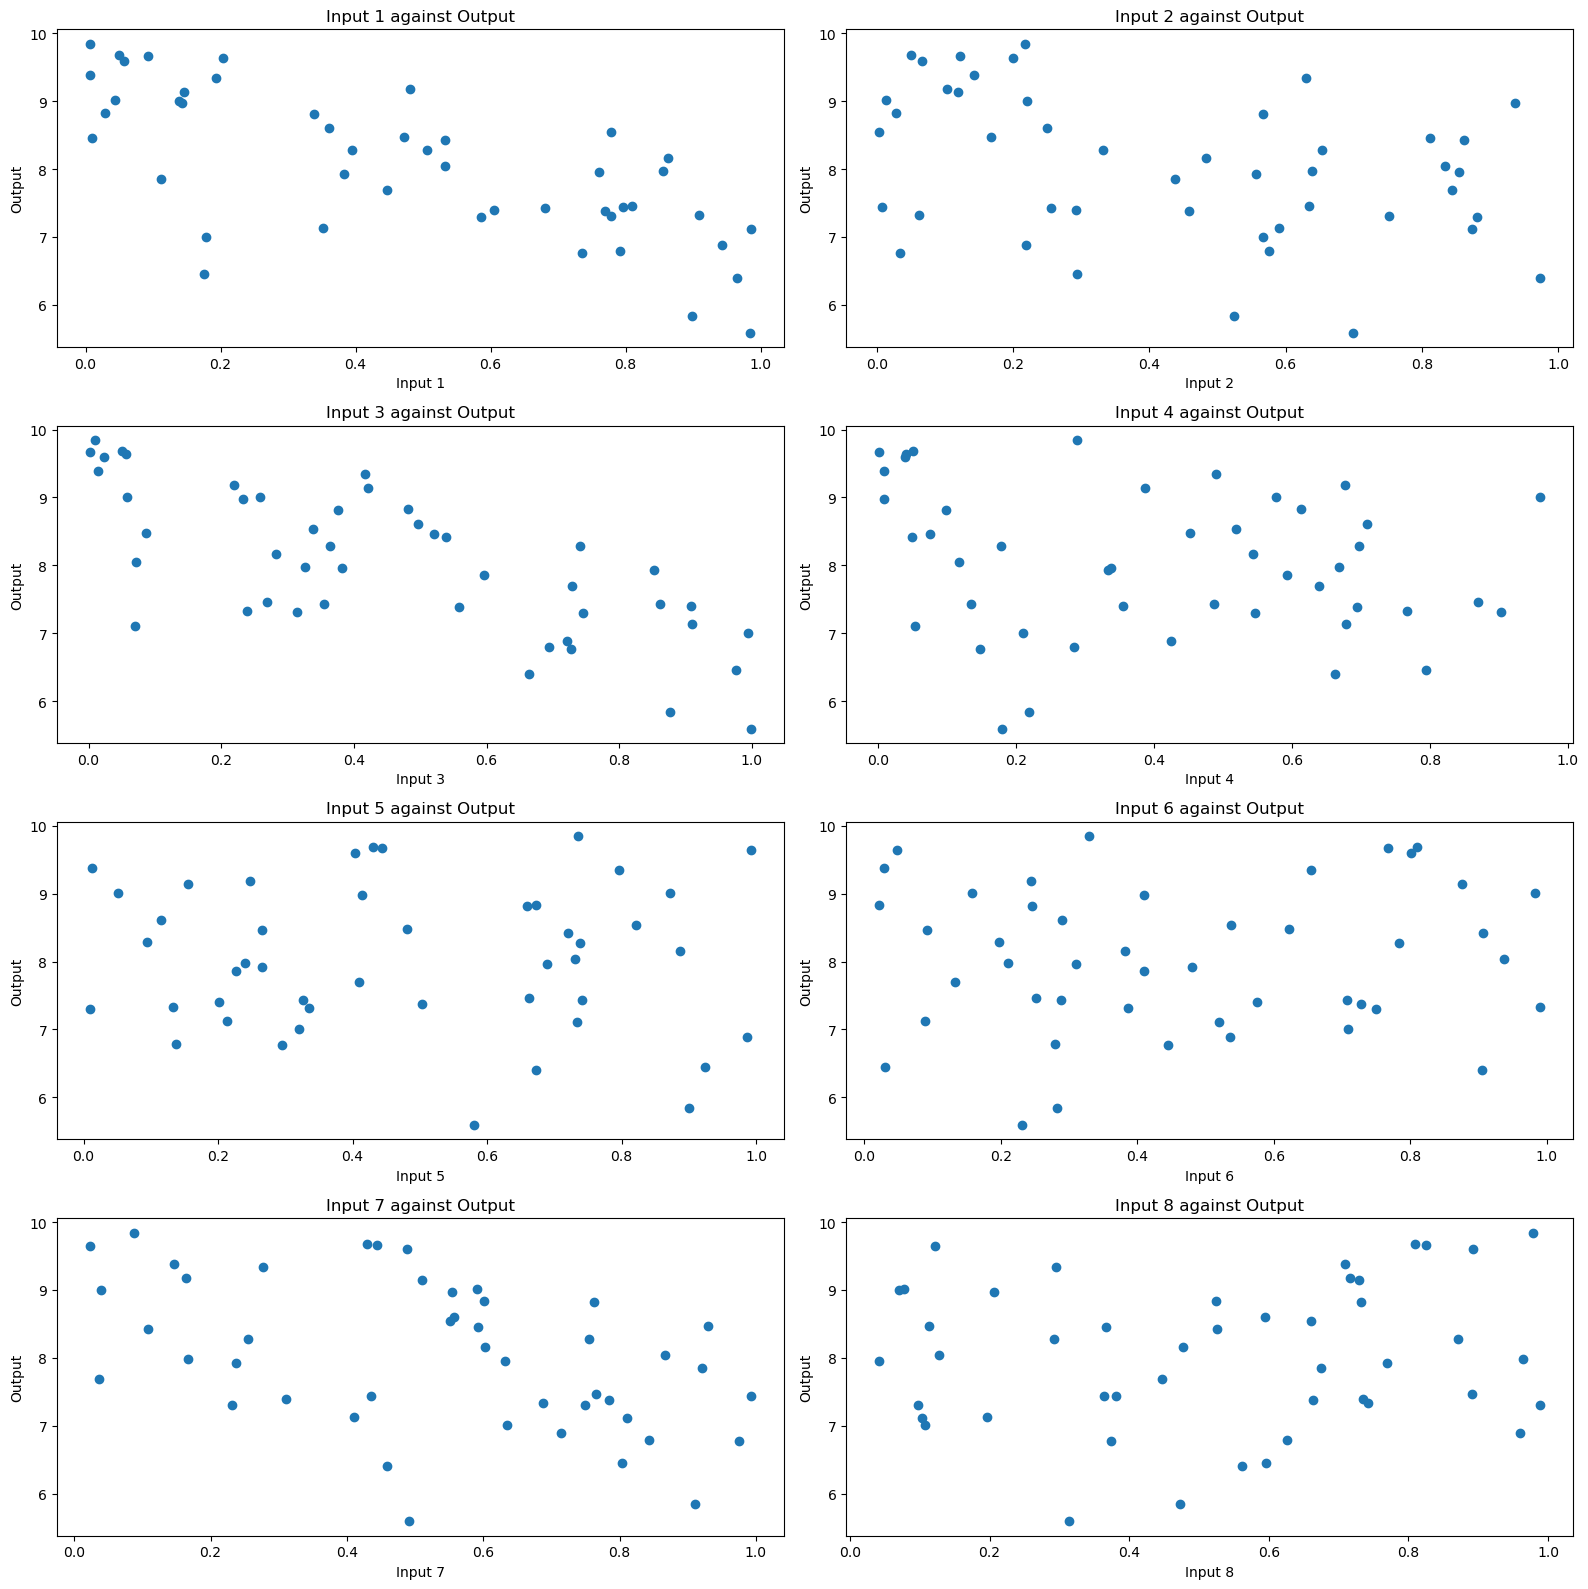

In [6]:
#Plotting each Input against the output
import matplotlib.pyplot as plt
fig, ax = plt.subplots(4,2, figsize = (16,16))

ax[0][0].scatter(X[:,0], Y)
ax[0][1].scatter(X[:,1], Y)
ax[1][0].scatter(X[:,2], Y)
ax[1][1].scatter(X[:,3], Y)
ax[2][0].scatter(X[:,4], Y)
ax[2][1].scatter(X[:,5], Y)
ax[3][0].scatter(X[:,6], Y)
ax[3][1].scatter(X[:,7], Y)

#Creating titles and axis labels
ax[0][0].set_title('Input 1 against Output')
ax[0][1].set_title('Input 2 against Output')
ax[1][0].set_title('Input 3 against Output')
ax[1][1].set_title('Input 4 against Output')
ax[2][0].set_title('Input 5 against Output')
ax[2][1].set_title('Input 6 against Output')
ax[3][0].set_title('Input 7 against Output')
ax[3][1].set_title('Input 8 against Output')

ax[0][0].set_xlabel('Input 1')
ax[0][0].set_ylabel('Output')

ax[0][1].set_xlabel('Input 2')
ax[0][1].set_ylabel('Output')

ax[1][0].set_xlabel('Input 3')
ax[1][0].set_ylabel('Output')

ax[1][1].set_xlabel('Input 4')
ax[1][1].set_ylabel('Output')

ax[2][0].set_xlabel('Input 5')
ax[2][0].set_ylabel('Output')

ax[2][1].set_xlabel('Input 6')
ax[2][1].set_ylabel('Output')

ax[3][0].set_xlabel('Input 7')
ax[3][0].set_ylabel('Output')

ax[3][1].set_xlabel('Input 8')
ax[3][1].set_ylabel('Output')

plt.tight_layout()
plt.show()

In [7]:
#We now use random forest regression to generate a list of promising points for a GP
#to evaluate
from sklearn.ensemble import RandomForestRegressor
#Using randomized search CV for light hyperparameter tuning
from sklearn.model_selection import RandomizedSearchCV

param_dist = {
    "n_estimators": [200, 300, 500],
    "max_depth": [None, 10, 20],
    "min_samples_leaf": [1, 2, 5],
    "max_features": [0.5, 0.7, 1.0]
}

rf = RandomForestRegressor(
    n_jobs=-1,
    random_state=42
)

search = RandomizedSearchCV(
    rf,
    param_distributions=param_dist,
    n_iter=10,
    cv=3,
    scoring="neg_mean_squared_error",
    n_jobs=-1, random_state = 42)

search.fit(X, Y.ravel())

rf_best = search.best_estimator_
print("Tuned RF Model:", rf_best)


Tuned RF Model: RandomForestRegressor(max_features=0.5, n_estimators=200, n_jobs=-1,
                      random_state=42)


In [8]:
#Use latin hypercube sampling to create a grid 
d = 8
n = 900000
sampler = qmc.LatinHypercube(d, seed = 42)
grid = sampler.random(n)   # samples in [0,1]^d

#Use random forest model to outputs from the grid
Y_pred = rf_best.predict(grid)

#Select the top 400 points
n_select = 400
top_idx = np.argsort(Y_pred)[-n_select:]
X_candidates = grid[top_idx]

In [9]:
#We now set the Kernel to be the Matern Kernel
nu = 2.5
kernel = Matern(length_scale=1.0, length_scale_bounds= (1e-2,1e1), nu = nu)
gp = GaussianProcessRegressor(
    kernel=kernel,
    alpha=1e-10,
    normalize_y = True)

gp.fit(X,Y)



#fit GP to candidate points suggested by Random Forest model
mu, std = gp.predict(X_candidates, return_std = True)

#fit GP to candidate points generated over entire domain
mu_grid, std_grid = gp.predict(grid, return_std = True)

In [10]:
#Calculate UCB 
beta = 1.96 #set exploration parameter
UCB = mu + beta*std 
UCB_grid = mu_grid + beta*std_grid 
X_next = X_candidates[np.argmax(UCB)]
X_next_grid = grid[np.argmax(UCB_grid)]
print("Random Forest Hybrid model next suggested point:", np.round(X_next,6))
print("Pure GP model next suggested point:", np.round(X_next_grid,6))

Random Forest Hybrid model next suggested point: [0.014396 0.156572 0.036172 0.30302  0.78578  0.313016 0.213195 0.543895]
Pure GP model next suggested point: [0.066684 0.472625 0.006665 0.427468 0.635343 0.455813 0.227135 0.388034]
